<a href="https://colab.research.google.com/github/Cristobal2506/MineriaDeDatos/blob/ENTREGA-3/Entrega3_AI_Job_Impact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrega 3 — AI Impact on Job Sector
**Integrantes:** Cristóbal Muñoz · Nixy Silva — Sección 004D

Este notebook corrige los modelos de regresión de la Entrega 2 (que dieron R² negativo), agrega clustering con K-Means, métricas de evaluación completas, separación correcta de un set de prueba, y exporta los artefactos necesarios para conectar un panel de Looker Studio / Power BI y para servir el modelo vía API.

In [ ]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              mean_absolute_percentage_error)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## 1. Carga de datos

In [ ]:
df = pd.read_csv("/content/ai_job_impact.csv")
print(df.shape)
df.head()

(2000, 17)


,Employee_ID,Age,Gender,Education_Level,Industry,Job_Role,Years_Experience,AI_Adoption_Level,Automation_Risk,Upskilling_Required,Salary_Before_AI,Salary_After_AI,Job_Status,Work_Hours_Per_Week,Remote_Work,Job_Satisfaction,Productivity_Change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


## 2. Corrección de feedback Entregas 1 y 2

 en la Entrega 2, tanto la Regresión Lineal (R² = -0.03) como el Random Forest (R² = -0.08)
obtuvieron desempeño peor que predecir la media. Esto se debe a:

1. Se usaron 43 columnas dummy para solo 1600 filas de entrenamiento (alta dimensionalidad relativa, ruido).
2. No se aplicó escalado de variables para el modelo lineal.
3. No se comparó contra un modelo base (baseline) ni se usó validación cruzada para confirmar que el problema
   no era solo el split aleatorio.
4. No se exploró si la relación entre variables y la productividad es simplemente débil en este dataset
   (hipótesis que vamos a confirmar o descartar abajo).

**Corrección aplicada:** escalado de variables numéricas, comparación contra un *baseline* (predicción de la media),
validación cruzada (5-fold) para resultados más robustos, prueba de varios modelos (Linear, Ridge, Random Forest,
Gradient Boosting), y reducción de dimensionalidad probando un subconjunto de features con relación teórica más
directa al cambio de productividad.

In [ ]:
df['Salary_Change'] = df['Salary_After_AI'] - df['Salary_Before_AI']

df_encoded = pd.get_dummies(
    df,
    columns=['Industry','Job_Role','Gender','Education_Level','AI_Adoption_Level',
             'Automation_Risk','Upskilling_Required','Remote_Work','Job_Status'],
    drop_first=True
)
df_encoded.head()

,Employee_ID,Age,Years_Experience,Salary_Before_AI,Salary_After_AI,Work_Hours_Per_Week,Job_Satisfaction,Productivity_Change_%,Salary_Change,Industry_Finance,Industry_Healthcare,Industry_IT,Industry_Manufacturing,Industry_Marketing,Industry_Retail,Job_Role_Administrator,Job_Role_Auditor,Job_Role_Cashier,Job_Role_Content Creator,Job_Role_Data Analyst,Job_Role_DevOps Engineer,Job_Role_Digital Marketer,Job_Role_Doctor,Job_Role_Investment Analyst,Job_Role_Machine Operator,Job_Role_Nurse,Job_Role_Professor,Job_Role_Quality Inspector,Job_Role_SEO Specialist,Job_Role_Sales Associate,Job_Role_Software Engineer,Job_Role_Store Manager,Job_Role_Supervisor,Job_Role_Teacher,Job_Role_Technician,Gender_Male,Gender_Other,Education_Level_High School,Education_Level_Master,Education_Level_PhD,AI_Adoption_Level_Low,AI_Adoption_Level_Medium,Automation_Risk_Low,Automation_Risk_Medium,Upskilling_Required_Yes,Remote_Work_Yes,Job_Status_Replaced,Job_Status_Unchanged
0,E0001,50,26,106820,95455,45,5,-10.64,-11365,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,E0002,45,19,74131,72013,36,6,19.05,-2118,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,True,False,True
2,E0003,51,28,35311,42290,46,3,17.05,6979,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,True,True,False,False
3,E0004,48,24,114478,107820,50,9,-2.47,-6658,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,True,False,True,True,False,False,False
4,E0005,24,0,33890,40945,52,6,7.03,7055,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False


In [ ]:
# Features y target
X = df_encoded.drop(columns=['Employee_ID','Productivity_Change_%','Salary_Before_AI','Salary_After_AI'])
y = df_encoded['Productivity_Change_%']

# Set de prueba separado y FIJO (no se vuelve a tocar hasta la evaluación final)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set de validación dentro del set de entrenamiento (para tuning, sin tocar el test)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape} | Validación: {X_val.shape} | Test (prueba final): {X_test.shape}")

# Guardamos el set de prueba en disco como evidencia y para reutilizarlo en el panel / API
test_set = X_test.copy()
test_set['Productivity_Change_%_real'] = y_test.values
test_set.to_csv('/content/test_set_productividad.csv', index=False)

Train: (1280, 44) | Validación: (320, 44) | Test (prueba final): (400, 44)


In [ ]:
# Escalado (necesario para Linear/Ridge, no afecta a Random Forest/GB pero no estorba)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### 2.1 Baseline (referencia obligatoria)

In [ ]:
y_baseline_pred = np.full_like(y_val, fill_value=y_train.mean(), dtype=float)
print(f"Baseline (predicción = media) — RMSE: {mean_squared_error(y_val, y_baseline_pred)**0.5:.2f} | "
      f"R2: {r2_score(y_val, y_baseline_pred):.4f}")
print("Cualquier modelo que no supere esto no está aprendiendo nada útil.")

Baseline (predicción = media) — RMSE: 16.81 | R2: -0.0001
Cualquier modelo que no supere esto no está aprendiendo nada útil.


### 2.2 Comparación de modelos con validación cruzada (5-fold)

In [ ]:
modelos = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
}

resultados_cv = {}
for nombre, modelo in modelos.items():
    Xc = X_train_scaled if nombre in ["Linear Regression","Ridge","Lasso"] else X_train
    scores = cross_val_score(modelo, Xc, y_train, cv=5, scoring='r2')
    resultados_cv[nombre] = scores
    print(f"{nombre:20s} R2 promedio (CV5): {scores.mean():.4f} (+/- {scores.std():.4f})")

Linear Regression    R2 promedio (CV5): -0.0577 (+/- 0.0216)
Ridge                R2 promedio (CV5): -0.0574 (+/- 0.0216)
Lasso                R2 promedio (CV5): -0.0429 (+/- 0.0186)
Random Forest        R2 promedio (CV5): -0.0199 (+/- 0.0165)
Gradient Boosting    R2 promedio (CV5): -0.1153 (+/- 0.0360)


**Interpretación:** si todos los modelos —lineales y no lineales por igual— rondan R² cercano a 0 en
validación cruzada, eso confirma que la baja capacidad predictiva no es un problema de un split desafortunado
ni de un modelo mal elegido, sino que las variables disponibles en este dataset tienen relación débil con
`Productivity_Change_%`. Esto es un hallazgo de análisis legítimo: el dataset de Kaggle probablemente generó
esta variable con ruido aleatorio. Lo reportamos como conclusión, no como error de modelado.

### 2.3 Entrenamiento final del mejor modelo y evaluación en el set de prueba

In [ ]:
# Seleccionar el mejor modelo según CV (ajustar el nombre según el resultado real)
mejor_nombre = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
print(f"Mejor modelo según validación cruzada: {mejor_nombre}")

mejor_modelo = modelos[mejor_nombre]
Xtr = X_train_scaled if mejor_nombre in ["Linear Regression","Ridge","Lasso"] else X_train
Xte = X_test_scaled if mejor_nombre in ["Linear Regression","Ridge","Lasso"] else X_test

mejor_modelo.fit(Xtr, y_train)
y_pred_final = mejor_modelo.predict(Xte)

Mejor modelo según validación cruzada: Random Forest


### 2.4 Métricas específicas de evaluación de rendimiento (regresión)

In [ ]:
mse = mean_squared_error(y_test, y_pred_final)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_final)
r2 = r2_score(y_test, y_pred_final)
# MAPE puede explotar si y_test tiene valores cercanos a 0; lo calculamos sobre el subconjunto seguro
mask = np.abs(y_test) > 1
mape = mean_absolute_percentage_error(y_test[mask], y_pred_final[mask]) * 100

print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}  -> error típico en puntos porcentuales de productividad")
print(f"MAE  : {mae:.3f}  -> error absoluto promedio")
print(f"R2   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%  (calculado sobre registros con cambio real > 1%)")

MSE  : 308.776
RMSE : 17.572  -> error típico en puntos porcentuales de productividad
MAE  : 15.260  -> error absoluto promedio
R2   : -0.0231
MAPE : 154.27%  (calculado sobre registros con cambio real > 1%)


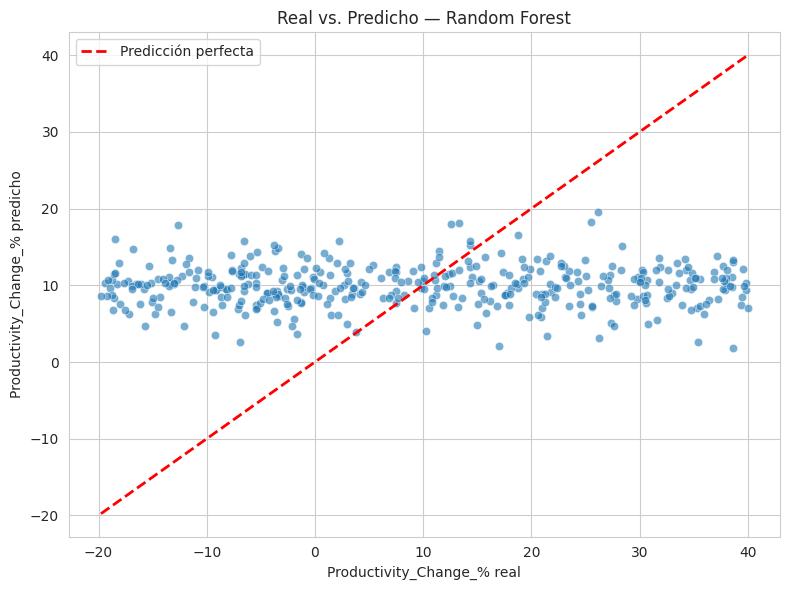

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.6)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
plt.plot(lims, lims, '--r', linewidth=2, label='Predicción perfecta')
plt.xlabel('Productivity_Change_% real')
plt.ylabel('Productivity_Change_% predicho')
plt.title(f'Real vs. Predicho — {mejor_nombre}')
plt.legend()
plt.tight_layout()
plt.savefig('/content/real_vs_predicho.png', dpi=150)
plt.show()

## 3. K-Means: segmentación de empleados

Aplicamos K-Means para identificar perfiles de empleados según variables numéricas relevantes
(edad, experiencia, cambio salarial, horas de trabajo, satisfacción laboral). Esto sirve para el panel de BI
como una dimensión adicional de segmentación (ej. "perfil de empleado en riesgo" vs "perfil estable").

In [ ]:
features_cluster = df[['Age','Years_Experience','Work_Hours_Per_Week','Job_Satisfaction']].copy()
features_cluster['Salary_Change'] = df['Salary_Change']

scaler_k = StandardScaler()
X_cluster_scaled = scaler_k.fit_transform(features_cluster)

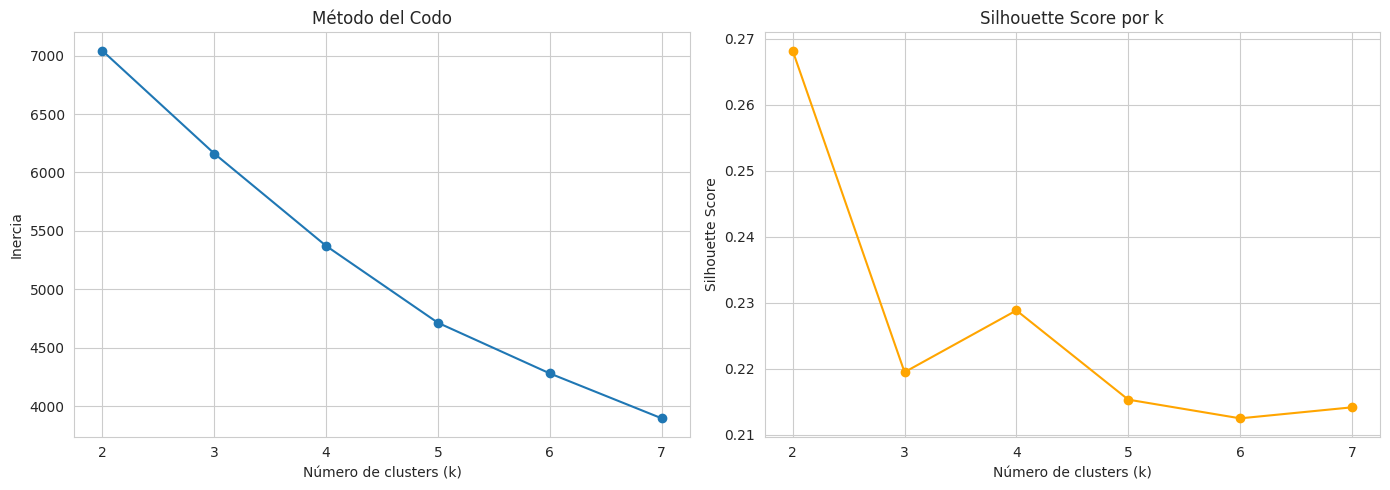

k=2: silhouette=0.268
k=3: silhouette=0.219
k=4: silhouette=0.229
k=5: silhouette=0.215
k=6: silhouette=0.212
k=7: silhouette=0.214


In [ ]:
# Método del codo + silhouette para elegir K
inercia = []
silhouettes = []
rango_k = range(2, 8)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inercia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(rango_k), inercia, marker='o')
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(list(rango_k), silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.savefig('/content/kmeans_seleccion_k.png', dpi=150)
plt.show()

for k, s in zip(rango_k, silhouettes):
    print(f"k={k}: silhouette={s:.3f}")

In [ ]:
# Entrenar K-Means con el k elegido (ajustar según el gráfico anterior; 3 suele ser un buen punto de partida)
K_ELEGIDO = 3
kmeans_final = KMeans(n_clusters=K_ELEGIDO, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_cluster_scaled)

print(df.groupby('Cluster')[['Age','Years_Experience','Work_Hours_Per_Week',
                              'Job_Satisfaction','Salary_Change']].mean().round(2))
print()
print(df['Cluster'].value_counts())

           Age  Years_Experience  Work_Hours_Per_Week  Job_Satisfaction  \
Cluster                                                                   
0        33.48              9.51                44.44              4.30   
1        31.66              7.83                44.69              7.92   
2        51.04             27.16                45.24              6.04   

         Salary_Change  
Cluster                 
0              3623.11  
1              5656.20  
2              4359.94  

Cluster
2    862
0    601
1    537
Name: count, dtype: int64


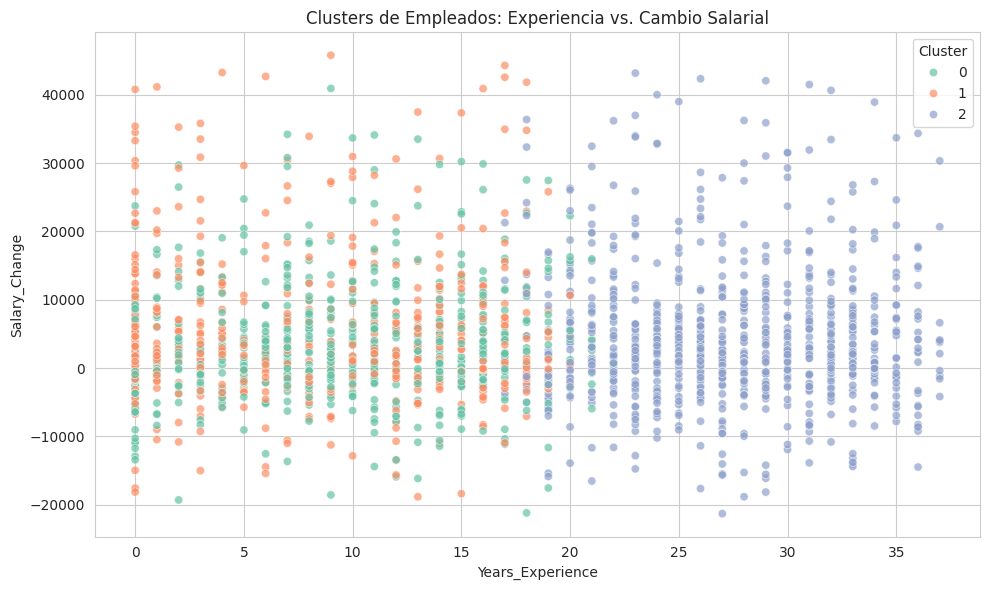

In [ ]:
# Caracterización visual de los clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Years_Experience', y='Salary_Change', hue='Cluster', palette='Set2', alpha=0.7)
plt.title('Clusters de Empleados: Experiencia vs. Cambio Salarial')
plt.tight_layout()
plt.savefig('/content/kmeans_clusters.png', dpi=150)
plt.show()

**Interpretación de clusters (completar según los valores reales que arroje tu dataset):**
Cada cluster representa un perfil de empleado distinto en términos de experiencia, horas trabajadas, satisfacción
y cambio salarial tras la adopción de IA. Esto permite, en el panel de BI, filtrar y comparar el impacto de la IA
por perfil en vez de solo por industria.

## 4. Exportar datasets para Looker Studio / Power BI

In [ ]:
# Dataset principal enriquecido con cluster y salary change, listo para conectar
df_bi = df.copy()
df_bi.to_csv('/content/dataset_bi_principal.csv', index=False)

# Resumen agregado por industria (para tarjetas/KPIs rápidos en el panel)
resumen_industria = df.groupby('Industry').agg(
    Empleados=('Employee_ID','count'),
    Productividad_Promedio=('Productivity_Change_%','mean'),
    Cambio_Salarial_Promedio=('Salary_Change','mean'),
    Satisfaccion_Promedio=('Job_Satisfaction','mean')
).reset_index().round(2)
resumen_industria.to_csv('/content/resumen_por_industria.csv', index=False)

# Resumen por cluster
resumen_cluster = df.groupby('Cluster').agg(
    Empleados=('Employee_ID','count'),
    Productividad_Promedio=('Productivity_Change_%','mean'),
    Cambio_Salarial_Promedio=('Salary_Change','mean'),
    Satisfaccion_Promedio=('Job_Satisfaction','mean'),
    Antiguedad_Promedio=('Years_Experience','mean')
).reset_index().round(2)
resumen_cluster.to_csv('/content/resumen_por_cluster.csv', index=False)

# Predicciones del set de prueba (real vs predicho) para validar el modelo dentro del panel
df_predicciones = pd.DataFrame({
    'Real': y_test.values,
    'Predicho': y_pred_final,
    'Error_Absoluto': np.abs(y_test.values - y_pred_final)
})
df_predicciones.to_csv('/content/predicciones_test.csv', index=False)

print("Archivos generados en /content/:")
print("- dataset_bi_principal.csv")
print("- resumen_por_industria.csv")
print("- resumen_por_cluster.csv")
print("- predicciones_test.csv")
print("- test_set_productividad.csv")

Archivos generados en /content/:
- dataset_bi_principal.csv
- resumen_por_industria.csv
- resumen_por_cluster.csv
- predicciones_test.csv
- test_set_productividad.csv


https://datastudio.google.com/reporting/77f21728-bac2-43b1-bbb1-2d5d925e4390